# Cross-Market Volatility Forecasting: Infosys vs Tesla

Comparing and forecasting the volatility of **Infosys (INFY)** — an Indian IT blue-chip —
and **Tesla (TSLA)** — a US high-growth technology stock — using GARCH(1,1) models.

**Objective:** Understand and quantify the risk characteristics of two stocks
from different markets, and produce short-term volatility forecasts.

---
**Data:** TwelveData API · ~12 years of daily OHLCV (2014–2026)  
**Model:** GARCH(1,1) · Selected via AIC across p,q ∈ {1,2,3}  
**Output:** Conditional volatility · 5-day forecast · Value at Risk (95%)

## 1. Setup & Data Collection

In [37]:
# Import your libraries here

import os
import sqlite3
from glob import glob

import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model
from arch.univariate.base import ARCHModelResult

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Force Python to reload modules fresh instead of using cached versions
import importlib
import model
importlib.reload(model)

from config import settings
from data import TwelveDataAPI, SQLRepository
from model import GarchModel, select_garch_order


In [38]:

print(settings.db_name)
print(settings.model_directory)
print(type(settings.twelvedata_api_key))  

stocks.sqlite
models
<class 'str'>


In [39]:
# Test API
api = TwelveDataAPI()
N_OBSERVATIONS = 3000

In [40]:
# Fetch data using the constant
df_infy = api.get_daily(ticker="INFY", outputsize=N_OBSERVATIONS)
print("INFY shape:", df_infy.shape)
print(df_infy.head())

INFY shape: (3000, 5)
             open   high    low  close      volume
date                                              
2026-06-05  12.76  12.82  12.39  12.40   8239000.0
2026-06-04  12.84  12.86  12.54  12.57  14882500.0
2026-06-03  12.87  12.88  12.35  12.46  17725700.0
2026-06-02  13.28  13.40  12.86  13.08  23013900.0
2026-06-01  12.72  13.56  12.72  13.41  34182100.0


In [41]:
# Fetch TSLA daily OHLCV data 
df_tsla = api.get_daily(ticker="TSLA", outputsize=N_OBSERVATIONS)
print("TSLA shape:", df_tsla.shape)
print(df_tsla.head())

TSLA shape: (3000, 5)
                 open       high        low      close      volume
date                                                              
2026-06-05  420.50000  424.67999  388.59000  391.00000  63128800.0
2026-06-04  419.84000  426.35001  417.16000  418.45001  35323300.0
2026-06-03  418.70001  433.60001  416.00000  423.70001  44500700.0
2026-06-02  418.22000  424.42001  413.64999  423.73999  37596000.0
2026-06-01  427.48999  429.60001  415.42999  415.88000  44937900.0


In [42]:
# Establish connection to local SQLite database
connection = sqlite3.connect(settings.db_name, check_same_thread=False)
repo = SQLRepository(connection=connection)

# Insert INFY and TSLA DataFrames into their respective tables
# if_exists="replace" ensures fresh data on every run
resp_infy = repo.insert_table(table_name="INFY", records=df_infy, if_exists="replace")
resp_tsla = repo.insert_table(table_name="TSLA", records=df_tsla, if_exists="replace")

print("INFY insert response:", resp_infy)
print("TSLA insert response:", resp_tsla)

INFY insert response: {'transaction_successful': True, 'records_inserted': 3000}
TSLA insert response: {'transaction_successful': True, 'records_inserted': 3000}


## 2. Data Processing

We read the stored data back from SQLite and compute **daily log returns**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) \times 100$$

Log returns are preferred over simple returns in financial modelling — they are
time-additive, approximately normally distributed, and better behaved statistically.

In [7]:
# Read stored data back from SQLite for both tickers
# Data is stored descending, so we sort ascending for time-series calculations
df_infy = repo.read_table(table_name="INFY", limit=N_OBSERVATIONS)
df_tsla = repo.read_table(table_name="TSLA", limit=N_OBSERVATIONS)

# Sort ascending by date (oldest first) for correct return calculation
df_infy.sort_index(ascending=True, inplace=True)
df_tsla.sort_index(ascending=True, inplace=True)

# Calculate daily log returns
df_infy["log_return"] = np.log(df_infy["close"] / df_infy["close"].shift(1)) * 100
df_tsla["log_return"] = np.log(df_tsla["close"] / df_tsla["close"].shift(1)) * 100

# Drop NaN introduced by shift (first row has no prior price)
df_infy.dropna(subset=["log_return"], inplace=True)
df_tsla.dropna(subset=["log_return"], inplace=True)

print("INFY shape after processing:", df_infy.shape)
print("TSLA shape after processing:", df_tsla.shape)
print("\nINFY date range:", df_infy.index.min(), "→", df_infy.index.max())
print("TSLA date range:", df_tsla.index.min(), "→", df_tsla.index.max())
print("\nSample INFY log returns:")
print(df_infy["log_return"].head())

INFY shape after processing: (2999, 6)
TSLA shape after processing: (2999, 6)

INFY date range: 2014-07-07 00:00:00 → 2026-06-05 00:00:00
TSLA date range: 2014-07-03 00:00:00 → 2026-06-05 00:00:00

Sample INFY log returns:
date
2014-07-07    3.385192
2014-07-08   -0.053991
2014-07-09   -0.940503
2014-07-10    1.120359
2014-07-11   -2.603223
Name: log_return, dtype: float64


## 3. Summary Statistics

Key metrics computed across the full 12-year history.

- **Annualised Return** = μ_daily × 252
- **Annualised Volatility** = σ_daily × √252  
  (variance scales linearly with time, so standard deviation scales with √time)

In [36]:
# Trading days in a year (excludes weekends and holidays)
TRADING_DAYS = 252

def summary_statistics(df, ticker):
    """
    Compute and display key descriptive statistics for a stock's log returns.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain a 'log_return' and 'close' column with DatetimeIndex.
    ticker : str
        Ticker symbol used for display purposes.
    
    Returns
    -------
    pd.Series
        Summary statistics series.
    """
    r = df["log_return"]
    
    # Annualized return: scale daily mean return by trading days
    ann_return = r.mean() * TRADING_DAYS
    
    # Annualized volatility: scale daily std by sqrt of trading days
    # (variance scales linearly, so std scales by sqrt)
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    
    stats = pd.Series({
        "Observations"        : len(r),
        "Mean Daily Return %"  : round(r.mean(), 4),
        "Std Daily Return %"   : round(r.std(), 4),
        "Min Daily Return %"   : round(r.min(), 4),
        "Max Daily Return %"   : round(r.max(), 4),
        "Skewness"            : round(r.skew(), 4),
        "Kurtosis"            : round(r.kurt(), 4),
        "Annualized Return %"  : round(ann_return, 4),
        "Annualized Volatility%": round(ann_vol, 4),
    }, name=ticker)
    
    return stats

stats_infy = summary_statistics(df_infy, "INFY")
stats_tsla = summary_statistics(df_tsla, "TSLA")

# Display side-by-side comparison
summary_df = pd.concat([stats_infy, stats_tsla], axis=1)
print("=" * 50)
print("     CROSS-MARKET SUMMARY STATISTICS")
print("=" * 50)
print(summary_df.to_string())

     CROSS-MARKET SUMMARY STATISTICS
                             INFY       TSLA
Observations            2999.0000  2999.0000
Mean Daily Return %        0.0204     0.1081
Std Daily Return %         1.7777     3.5531
Min Daily Return %       -12.9081   -23.6518
Max Daily Return %        11.7468    20.4491
Skewness                  -0.3407    -0.0501
Kurtosis                   6.6456     4.4613
Annualized Return %        5.1523    27.2348
Annualized Volatility%    28.2204    56.4044


## 4. Exploratory Data Analysis (EDA)

Visual inspection of price history, return behaviour, and volatility regimes.

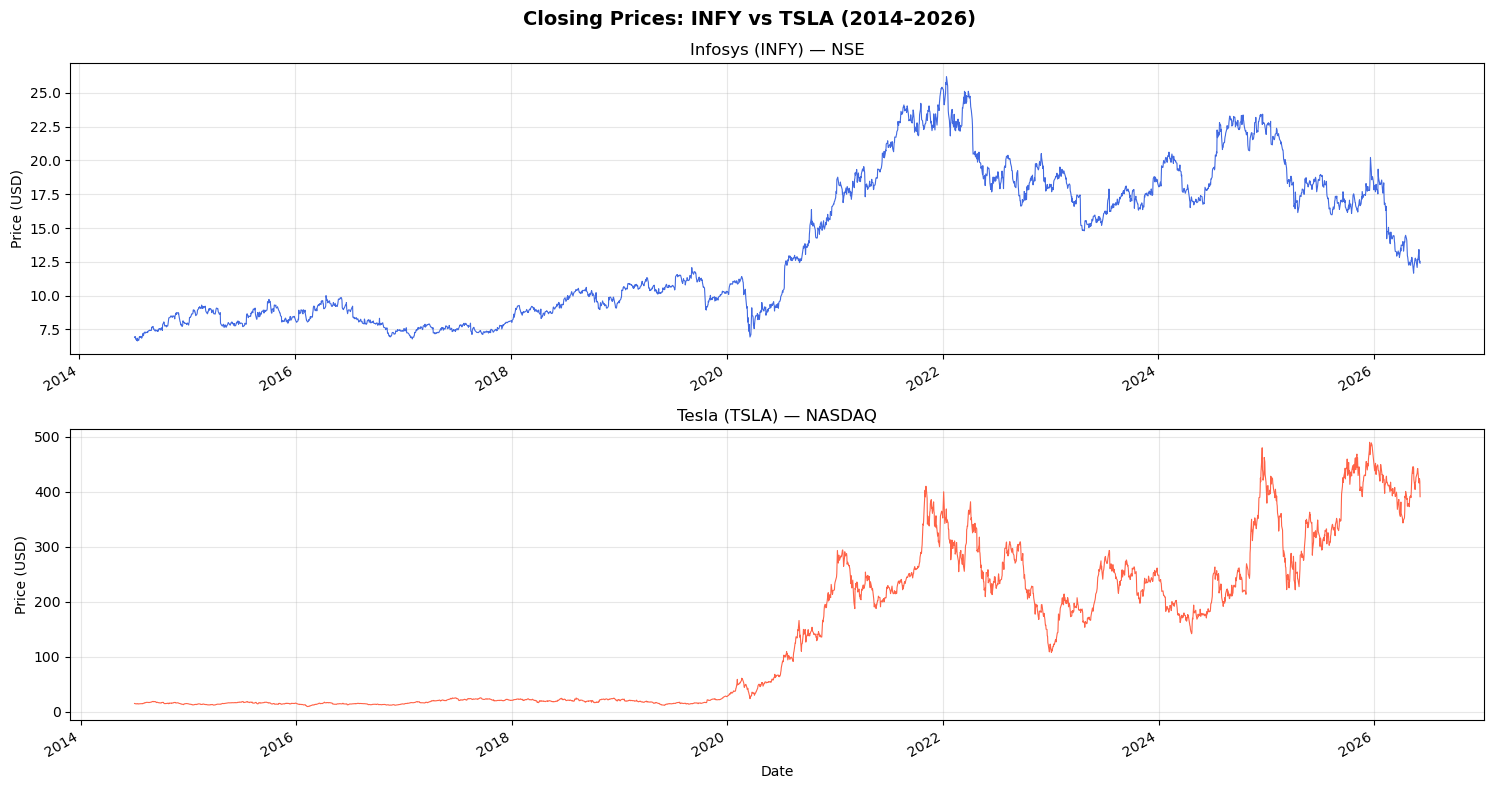

In [9]:
# EDA: Closing Prices 
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
fig.suptitle("Closing Prices: INFY vs TSLA (2014–2026)", fontsize=14, fontweight="bold")

# INFY closing price
df_infy["close"].plot(ax=axes[0], color="royalblue", linewidth=0.8)
axes[0].set_title("Infosys (INFY) — NSE")
axes[0].set_ylabel("Price (USD)")
axes[0].set_xlabel("")
axes[0].grid(alpha=0.3)

# TSLA closing price
df_tsla["close"].plot(ax=axes[1], color="tomato", linewidth=0.8)
axes[1].set_title("Tesla (TSLA) — NASDAQ")
axes[1].set_ylabel("Price (USD)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/closing_prices.png", dpi=150, bbox_inches="tight")
plt.show()

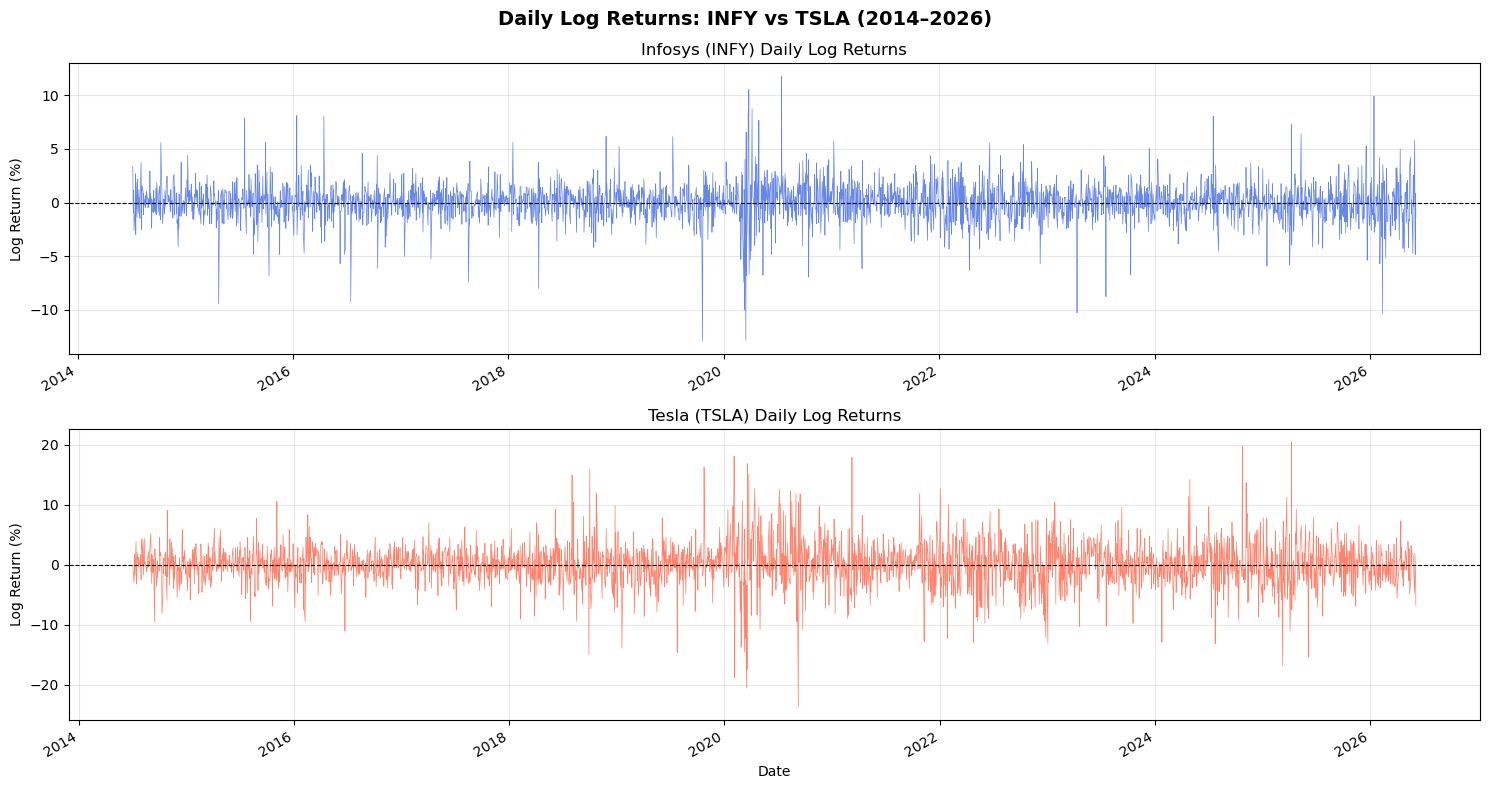

In [10]:
# EDA: Daily Log Returns 
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
fig.suptitle("Daily Log Returns: INFY vs TSLA (2014–2026)", fontsize=14, fontweight="bold")

# INFY returns
df_infy["log_return"].plot(ax=axes[0], color="royalblue", linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Infosys (INFY) Daily Log Returns")
axes[0].set_ylabel("Log Return (%)")
axes[0].set_xlabel("")
axes[0].grid(alpha=0.3)

# TSLA returns
df_tsla["log_return"].plot(ax=axes[1], color="tomato", linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Tesla (TSLA) Daily Log Returns")
axes[1].set_ylabel("Log Return (%)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/daily_returns.png", dpi=150, bbox_inches="tight")
plt.show()

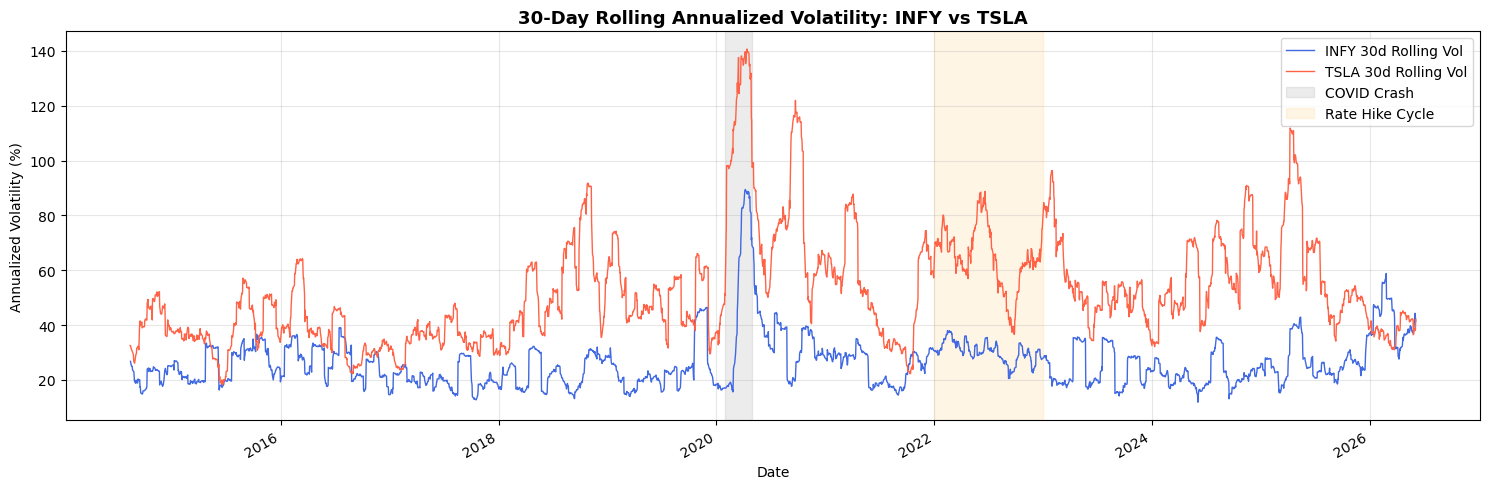

In [11]:
# EDA: Rolling 30-Day Volatility 
# Rolling std approximates short-term volatility regime changes
ROLLING_WINDOW = 30

infy_rolling_vol = df_infy["log_return"].rolling(window=ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)
tsla_rolling_vol = df_tsla["log_return"].rolling(window=ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(15, 5))
infy_rolling_vol.plot(ax=ax, color="royalblue", linewidth=1, label="INFY 30d Rolling Vol")
tsla_rolling_vol.plot(ax=ax, color="tomato", linewidth=1, label="TSLA 30d Rolling Vol")

# Annotate key market events
ax.axvspan("2020-02-01", "2020-04-30", alpha=0.15, color="gray", label="COVID Crash")
ax.axvspan("2022-01-01", "2022-12-31", alpha=0.10, color="orange", label="Rate Hike Cycle")

ax.set_title("30-Day Rolling Annualized Volatility: INFY vs TSLA", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

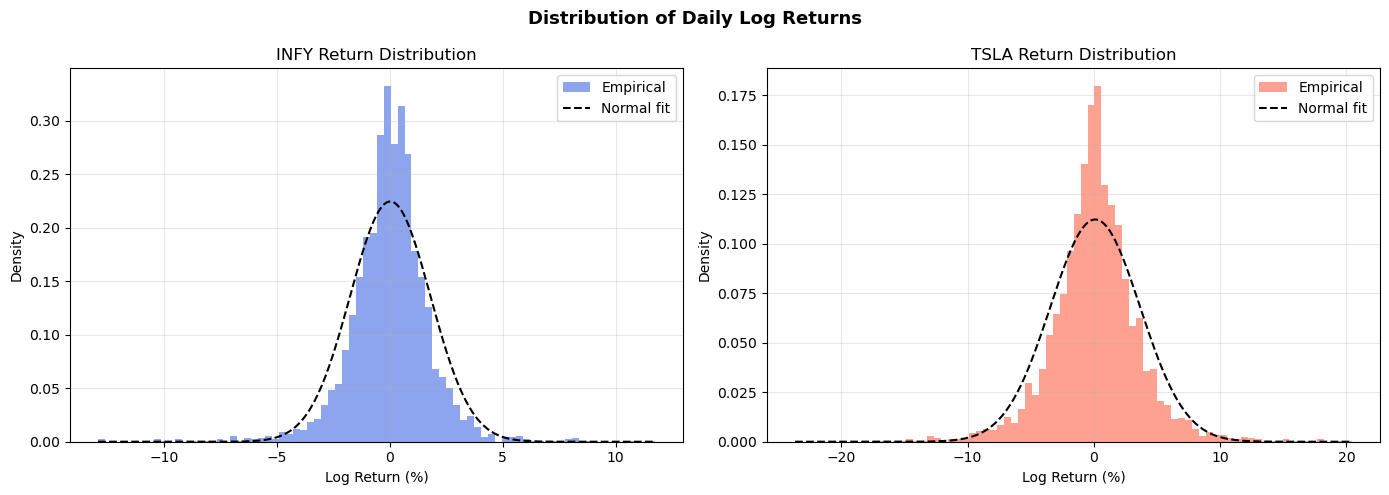

In [12]:
# EDA: Return Distributions
# Histograms reveal skewness, kurtosis and fat tails vs normal distribution
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of Daily Log Returns", fontsize=13, fontweight="bold")

for ax, df, ticker, color in zip(
    axes,
    [df_infy, df_tsla],
    ["INFY", "TSLA"],
    ["royalblue", "tomato"]
):
    r = df["log_return"]
    ax.hist(r, bins=80, density=True, color=color, alpha=0.6, label="Empirical")
    
    # Overlay normal distribution for comparison
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, norm.pdf(x, r.mean(), r.std()), "k--", linewidth=1.5, label="Normal fit")
    
    ax.set_title(f"{ticker} Return Distribution")
    ax.set_xlabel("Log Return (%)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### ACF & PACF of Squared Returns

We square the returns before plotting ACF/PACF because volatility clustering
manifests in the **magnitude** of returns, regardless of direction.

Significant autocorrelation in squared returns confirms the presence of an
**ARCH effect** — justifying the use of a GARCH model.

The PACF cut-off point guides the choice of `p` and `q` parameters.

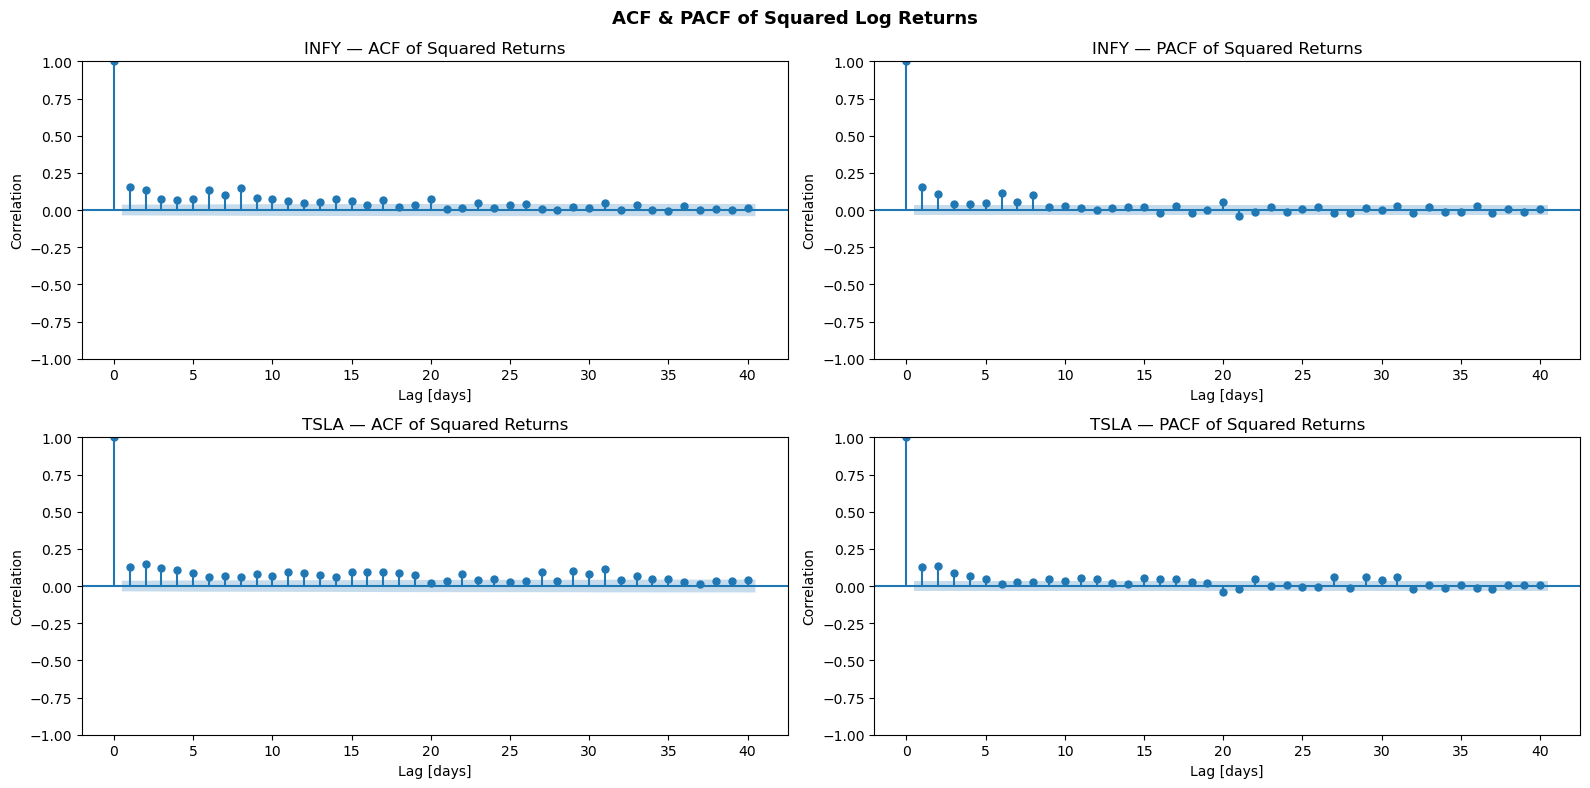

In [13]:
# EDA: ACF & PACF of Squared Returns

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("ACF & PACF of Squared Log Returns", fontsize=13, fontweight="bold")

# INFY ACF
plot_acf(df_infy["log_return"]**2, ax=axes[0, 0], lags=40, alpha=0.05)
axes[0, 0].set_title("INFY — ACF of Squared Returns")
axes[0, 0].set_xlabel("Lag [days]")
axes[0, 0].set_ylabel("Correlation")

# INFY PACF
plot_pacf(df_infy["log_return"]**2, ax=axes[0, 1], lags=40, alpha=0.05)
axes[0, 1].set_title("INFY — PACF of Squared Returns")
axes[0, 1].set_xlabel("Lag [days]")
axes[0, 1].set_ylabel("Correlation")

# TSLA ACF
plot_acf(df_tsla["log_return"]**2, ax=axes[1, 0], lags=40, alpha=0.05)
axes[1, 0].set_title("TSLA — ACF of Squared Returns")
axes[1, 0].set_xlabel("Lag [days]")
axes[1, 0].set_ylabel("Correlation")

# TSLA PACF
plot_pacf(df_tsla["log_return"]**2, ax=axes[1, 1], lags=40, alpha=0.05)
axes[1, 1].set_title("TSLA — PACF of Squared Returns")
axes[1, 1].set_xlabel("Lag [days]")
axes[1, 1].set_ylabel("Correlation")

plt.tight_layout()
# plt.savefig("plots/acf_pacf_squared_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Volatility Modelling — GARCH(p,q)

The **GARCH(1,1)** model estimates conditional variance as:

$$\sigma^2_t = \omega + \alpha \cdot \varepsilon^2_{t-1} + \beta \cdot \sigma^2_{t-1}$$

Where:
- **ω** = long-run variance constant
- **α** (alpha) = sensitivity to recent return shocks
- **β** (beta) = persistence of past volatility

We test p, q ∈ {1, 2, 3} and select the best specification using **AIC** (lower = better).

In [14]:
infy_returns = df_infy["log_return"]
tsla_returns = df_tsla["log_return"]

df_infy_orders, best_p_infy, best_q_infy = select_garch_order(infy_returns, "INFY")
df_tsla_orders, best_p_tsla, best_q_tsla = select_garch_order(tsla_returns, "TSLA")


GARCH Order Selection — INFY
   p    q          AIC          BIC       LogLik
   1    1    11730.710    11754.734    -5861.355
   1    2    11722.308    11752.338    -5856.154
   1    3    11707.492    11743.529    -5847.746
   2    1    11732.710    11762.740    -5861.355
   2    2    11724.308    11760.344    -5856.154
   2    3    11709.492    11751.535    -5847.746
   3    1    11734.710    11770.746    -5861.355
   3    2    11726.308    11768.350    -5856.154
   3    3    11711.492    11759.541    -5847.746

Best: GARCH(1,3) — AIC=11707.492, BIC=11743.529

GARCH Order Selection — TSLA
   p    q          AIC          BIC       LogLik
   1    1    15710.625    15734.649    -7851.312
   1    2    15712.318    15742.348    -7851.159
   1    3    15713.182    15749.219    -7850.591
   2    1    15712.625    15742.655    -7851.312
   2    2    15710.792    15746.828    -7849.396
   2    3    15714.335    15756.377    -7850.167
   3    1    15714.625    15750.661    -7851.312
   3    2

## Final Model Selection 

In [15]:
# Fit final models
model_infy = arch_model(infy_returns, p=best_p_infy, q=best_q_infy, rescale=False).fit(disp=0)
model_tsla = arch_model(tsla_returns, p=best_p_tsla, q=best_q_tsla, rescale=False).fit(disp=0)

print(model_infy.summary())
print(model_tsla.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5847.75
Distribution:                  Normal   AIC:                           11707.5
Method:            Maximum Likelihood   BIC:                           11743.5
                                        No. Observations:                 2999
Date:                Sat, Jun 06 2026   Df Residuals:                     2998
Time:                        15:38:03   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0492  3.400e-02      1.447      0.148 [-1.74

In [16]:
# coefficients table

coef_infy = pd.DataFrame({
    "INFY_coef"   : model_infy.params.round(6),
    "INFY_std_err": model_infy.std_err.round(6),
    "INFY_pvalue" : model_infy.pvalues.round(4)
})
coef_tsla = pd.DataFrame({
    "TSLA_coef"   : model_tsla.params.round(6),
    "TSLA_std_err": model_tsla.std_err.round(6),
    "TSLA_pvalue" : model_tsla.pvalues.round(4)
})

coef_table = pd.concat([coef_infy, coef_tsla], axis=1)

print("  Model Coefficients: INFY vs TSLA")

print(coef_table.to_string())
print(f"\nINFY — AIC: {model_infy.aic:.3f}  |  BIC: {model_infy.bic:.3f}")
print(f"TSLA — AIC: {model_tsla.aic:.3f}  |  BIC: {model_tsla.bic:.3f}")

  Model Coefficients: INFY vs TSLA
          INFY_coef  INFY_std_err  INFY_pvalue  TSLA_coef  TSLA_std_err  TSLA_pvalue
mu         0.049183      0.033998       0.1480   0.078861      0.057861       0.1729
omega      0.592517      0.507727       0.2432   0.100116      0.054637       0.0669
alpha[1]   0.144797      0.070446       0.0398   0.033023      0.009434       0.0005
beta[1]    0.251676      0.374846       0.5020   0.959276      0.012560       0.0000
beta[2]    0.000000      0.943441       1.0000        NaN           NaN          NaN
beta[3]    0.414786      0.705709       0.5567        NaN           NaN          NaN

INFY — AIC: 11707.492  |  BIC: 11743.529
TSLA — AIC: 15710.625  |  BIC: 15734.649


## 6. Conditional Volatility

The GARCH model produces a time-varying estimate of volatility at each point in history.
Spikes correspond to real-world market stress events — most notably the **COVID crash (2020)**
and the **2022 rate hike cycle**.

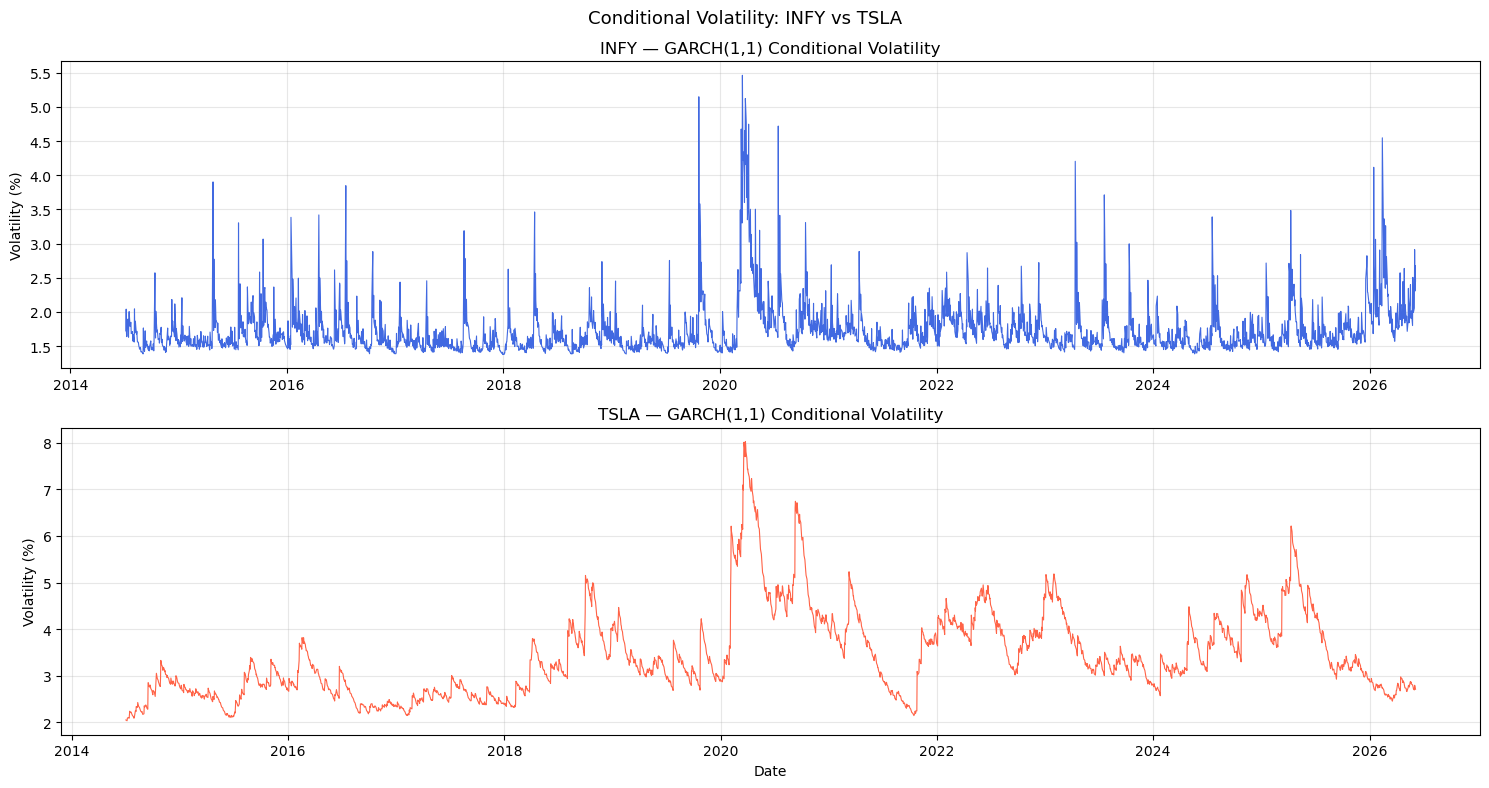

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
fig.suptitle("Conditional Volatility: INFY vs TSLA", fontsize=13)

axes[0].plot(model_infy.conditional_volatility, color="royalblue", linewidth=0.8)
axes[0].set_title("INFY — GARCH(1,1) Conditional Volatility")
axes[0].set_ylabel("Volatility (%)")
axes[0].grid(alpha=0.3)

axes[1].plot(model_tsla.conditional_volatility, color="tomato", linewidth=0.8)
axes[1].set_title("TSLA — GARCH(1,1) Conditional Volatility")
axes[1].set_ylabel("Volatility (%)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/conditional_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Volatility Forecast — 5 Trading Days

The model projects current volatility forward 5 trading days. Two forces drive the forecast:

- **Starting point** — where volatility is right now
- **Mean reversion** — volatility always drifts back toward its long-run average over time

How fast it reverts depends on **persistence (α + β)**. Both stocks have persistence close to 1, meaning a volatility spike today is still mostly present a week later.

Forecast values are **annualised volatility (%)** — the standard unit in options pricing and risk reports.

In [18]:
horizon = 5

# Generate variance forecasts and take square root to get volatility
infy_forecast = model_infy.forecast(horizon=horizon, reindex=False).variance ** 0.5
tsla_forecast = model_tsla.forecast(horizon=horizon, reindex=False).variance ** 0.5

# Build date index for next 5 business days
infy_dates = pd.bdate_range(start=infy_returns.index[-1] + pd.DateOffset(days=1), periods=horizon)
tsla_dates = pd.bdate_range(start=tsla_returns.index[-1] + pd.DateOffset(days=1), periods=horizon)

infy_pred = pd.Series(infy_forecast.values.flatten(), index=infy_dates)
tsla_pred = pd.Series(tsla_forecast.values.flatten(), index=tsla_dates)

forecast_df = pd.DataFrame({
    "INFY_volatility": infy_pred.round(4),
    "TSLA_volatility": tsla_pred.round(4)
})

print("5-Day Volatility Forecast (%)")
print(forecast_df.to_string())

5-Day Volatility Forecast (%)
            INFY_volatility  TSLA_volatility
2026-06-08           2.1438           2.9471
2026-06-09           2.3210           2.9527
2026-06-10           2.2850           2.9583
2026-06-11           2.1375           2.9638
2026-06-12           2.1537           2.9693


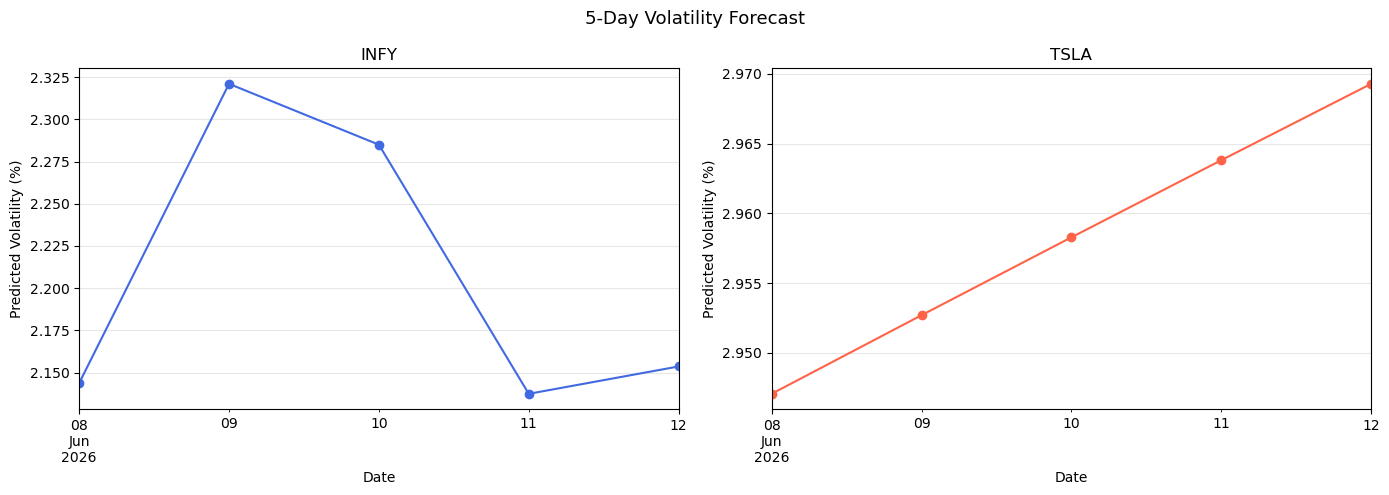

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5-Day Volatility Forecast", fontsize=13)

infy_pred.plot(ax=axes[0], marker="o", color="royalblue")
axes[0].set_title("INFY")
axes[0].set_ylabel("Predicted Volatility (%)")
axes[0].set_xlabel("Date")
axes[0].grid(alpha=0.3)

tsla_pred.plot(ax=axes[1], marker="o", color="tomato")
axes[1].set_title("TSLA")
axes[1].set_ylabel("Predicted Volatility (%)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/volatility_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
joblib.dump(model_infy, "models/model_infy.pkl")
joblib.dump(model_tsla, "models/model_tsla.pkl")

print("Models saved.")

Models saved.


## 8. Summary

In [21]:
print("Cross-Market Volatility Forecasting — Final Summary\n")

infy_persistence = model_infy.params["alpha[1]"] + model_infy.params["beta[1]"]
tsla_persistence = model_tsla.params["alpha[1]"] + model_tsla.params["beta[1]"]

print(f"{'':30} {'INFY':>10} {'TSLA':>10}")
print(f"{'Annualized Volatility %':<30} {28.22:>10} {56.40:>10}")
print(f"{'Persistence (alpha+beta)':<30} {infy_persistence:>10.4f} {tsla_persistence:>10.4f}")
print(f"{'AIC':<30} {model_infy.aic:>10.2f} {model_tsla.aic:>10.2f}")
print(f"{'5d Avg Forecast Vol %':<30} {infy_pred.mean():>10.4f} {tsla_pred.mean():>10.4f}")

Cross-Market Volatility Forecasting — Final Summary

                                     INFY       TSLA
Annualized Volatility %             28.22       56.4
Persistence (alpha+beta)           0.3965     0.9923
AIC                              11707.49   15710.62
5d Avg Forecast Vol %              2.2082     2.9582


## 9. Residual Diagnostics

A well-fitted GARCH model should produce **standardised residuals** that are:
- Roughly normally distributed and centred at zero
- Random with no obvious patterns over time (no remaining volatility clustering)

Any remaining structure in the residuals would suggest the model has missed something.

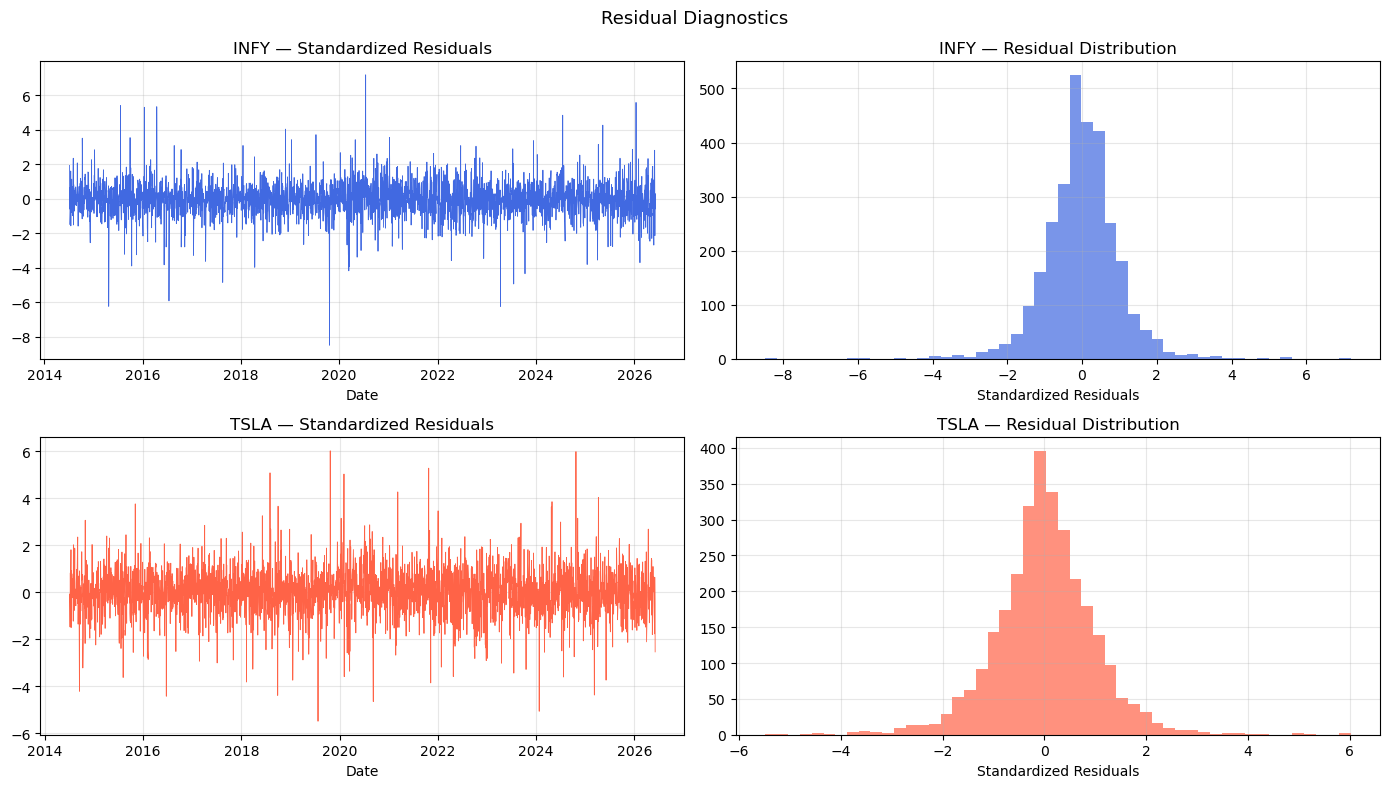

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Residual Diagnostics", fontsize=13)

# INFY standardized residuals
axes[0, 0].plot(model_infy.std_resid, color="royalblue", linewidth=0.6)
axes[0, 0].set_title("INFY — Standardized Residuals")
axes[0, 0].set_xlabel("Date")
axes[0, 0].grid(alpha=0.3)

# INFY residuals histogram
axes[0, 1].hist(model_infy.std_resid, bins=50, color="royalblue", alpha=0.7)
axes[0, 1].set_title("INFY — Residual Distribution")
axes[0, 1].set_xlabel("Standardized Residuals")
axes[0, 1].grid(alpha=0.3)

# TSLA standardized residuals
axes[1, 0].plot(model_tsla.std_resid, color="tomato", linewidth=0.6)
axes[1, 0].set_title("TSLA — Standardized Residuals")
axes[1, 0].set_xlabel("Date")
axes[1, 0].grid(alpha=0.3)

# TSLA residuals histogram
axes[1, 1].hist(model_tsla.std_resid, bins=50, color="tomato", alpha=0.7)
axes[1, 1].set_title("TSLA — Residual Distribution")
axes[1, 1].set_xlabel("Standardized Residuals")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("plots/residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# test /hello
# response = requests.get("http://localhost:8008/hello")
# print(response.json())

{'message': 'Hello World!'}


## 10. API Testing

Testing the FastAPI endpoints we built in `main.py`.
The `/fit` endpoint trains and saves a GARCH model for a given ticker.
The `/predict` endpoint loads the saved model and returns a 5-day volatility forecast.

Make sure the server is running before executing these cells:
```
uvicorn main:app --reload --workers 1 --host localhost --port 8008
```

### `/fit` — Train Models

In [25]:
# fit INFY model via API
response = requests.post(
    "http://localhost:8008/fit",
    json={
        "ticker": "INFY",
        "use_new_data": False,
        "n_observations": 3000,
        "p": 1,
        "q": 1
    }
)
print(response.json())

{'ticker': 'INFY', 'use_new_data': False, 'n_observations': 3000, 'p': 1, 'q': 1, 'success': True, 'message': "Trained and saved 'models/2026-06-06T15:39:04.835815_INFY.pkl'.Metrics: AIC 3.911540396631896, BIC 3.9195511124421647."}


In [26]:
# fit TSLA model via API
response = requests.post(
    "http://localhost:8008/fit",
    json={
        "ticker": "TSLA",
        "use_new_data": False,
        "n_observations": 3000,
        "p": 1,
        "q": 1
    }
)
print(response.json())

{'ticker': 'TSLA', 'use_new_data': False, 'n_observations': 3000, 'p': 1, 'q': 1, 'success': True, 'message': "Trained and saved 'models/2026-06-06T15:39:05.344876_TSLA.pkl'.Metrics: AIC 5.2386210544612295, BIC 5.246631770271498."}


### `/predict` — Get Forecasts

In [27]:
# get 5-day forecast for INFY
response = requests.post(
    "http://localhost:8008/predict",
    json={"ticker": "INFY", "n_days": 5}
)
print(response.json())

{'ticker': 'INFY', 'n_days': 5, 'success': True, 'forecast': {'2026-06-08T00:00:00': 2.0302249615562356, '2026-06-09T00:00:00': 1.9536664532023573, '2026-06-10T00:00:00': 1.8996783880809973, '2026-06-11T00:00:00': 1.861956477099316, '2026-06-12T00:00:00': 1.8357825584339482}, 'message': ''}


In [28]:
# get 5-day forecast for TSLA
response = requests.post(
    "http://localhost:8008/predict",
    json={"ticker": "TSLA", "n_days": 5}
)
print(response.json())

{'ticker': 'TSLA', 'n_days': 5, 'success': True, 'forecast': {'2026-06-08T00:00:00': 2.9470671681046285, '2026-06-09T00:00:00': 2.9526994910108617, '2026-06-10T00:00:00': 2.9582778385203357, '2026-06-11T00:00:00': 2.963802847877114, '2026-06-12T00:00:00': 2.9692751461291707}, 'message': ''}


## 11. Value at Risk (VaR) — 95% Confidence

VaR answers: *"What is the maximum daily loss I can expect on 95% of trading days?"*

Using the parametric approach with our GARCH volatility forecast:

$$\text{VaR}_{95\%} = -(\mu - 1.645 \times \sigma_{\text{forecast}})$$

Where 1.645 is the z-score for the 95th percentile of the normal distribution (one-tailed).

In [31]:


Z_95 = 1.645

infy_mean = infy_returns.mean()
tsla_mean = tsla_returns.mean()

print("Value at Risk (95% Confidence Level)\n")
print(f"{'':30} {'INFY':>10} {'TSLA':>10}")
print("-" * 52)

for i, (date, infy_vol, tsla_vol) in enumerate(
    zip(infy_pred.index, infy_pred.values, tsla_pred.values)
):
    infy_var = -(infy_mean - Z_95 * infy_vol)
    tsla_var = -(tsla_mean - Z_95 * tsla_vol)
    print(f"{str(date.date()):<30} {infy_var:>9.4f}% {tsla_var:>9.4f}%")

print("\nInterpretation:")
print(f"  INFY: On 95% of days, daily loss will not exceed ~{-(infy_mean - Z_95 * infy_pred.mean()):.2f}%")
print(f"  TSLA: On 95% of days, daily loss will not exceed ~{-(tsla_mean - Z_95 * tsla_pred.mean()):.2f}%")

Value at Risk (95% Confidence Level)

                                     INFY       TSLA
----------------------------------------------------
2026-06-08                        3.5061%    4.7399%
2026-06-09                        3.7976%    4.7491%
2026-06-10                        3.7383%    4.7583%
2026-06-11                        3.4957%    4.7674%
2026-06-12                        3.5224%    4.7764%

Interpretation:
  INFY: On 95% of days, daily loss will not exceed ~3.61%
  TSLA: On 95% of days, daily loss will not exceed ~4.76%
